In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [111]:
test = pd.read_csv("/Users/hayashieijun/Desktop/airline-satisfaction-classification/data/test.csv")
train = pd.read_csv("/Users/hayashieijun/Desktop/airline-satisfaction-classification/data/train.csv")

In [112]:
train['Class'].unique()

array(['Eco Plus', 'Business', 'Eco'], dtype=object)

In [113]:
#preprocess data
def encode_gender(x):
    if x == 'Female':
        return 1
    elif x == 'Male':
        return 0
    else:
        return -1
    
def encode_customer_type(x):
    if x == 'Loyal Customer':
        return 1
    elif x == 'disloyal Customer':
        return 0
    else:
        return -1
    
def encode_type_of_travel(x):
    if x == 'Business travel':
        return 1
    elif x == 'Personal Travel':
        return 0
    else:
        return -1
    
def encode_class(x):
    if x == 'Business':
        return 2
    elif x == 'Eco Plus':
        return 1
    elif x == 'Eco':
        return 0
    else:
        return -1
    
def encode_satisfaction(x):
    if x == 'satisfied':
        return 1
    elif x == 'neutral or dissatisfied':
        return 0
    else:
        return -1 

In [114]:
def preprocess_data(df):
    #drop meaningless columns
    df = df.drop(columns=['id', 'Unnamed: 0'])

    #encode
    df['Gender'] = df['Gender'].apply(encode_gender)
    df['Customer Type'] = df['Customer Type'].apply(encode_customer_type)
    df['Type of Travel'] = df['Type of Travel'].apply(encode_type_of_travel)
    df['Class'] = df['Class'].apply(encode_class)
    df['satisfaction'] = df['satisfaction'].apply(encode_satisfaction)

    #feature engineering
    df['Age Group'] = pd.cut(df['Age'], bins=[0, 18, 30, 50, 100], labels=[0, 1, 2, 3])
    df['Flight Distance Group'] = pd.cut(df['Flight Distance'], bins=[0, 500, 1500, 3000, 5000], labels=[0, 1, 2, 3])
    df['Total Delay']  = df[['Departure Delay in Minutes', 'Arrival Delay in Minutes']].sum(axis=1)
    df['Service Score Average'] = (df['On-board service'] + df['Checkin service'] + df['Inflight service'] + df['Inflight wifi service']) / 4

    #drop original columns after feature engineering and original encoded columns
    df = df.drop(columns = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'On-board service', 'Checkin service', 'Inflight service', 'Inflight wifi service', 'Customer Type', 'Type of Travel'], errors='ignore')

    #drop the columns that are not used for modeling
    df = df.drop(columns = ['Departure/Arrival time convenient', 'Gate location'], errors='ignore')
    return df

train_processed = preprocess_data(train)
test_processed = preprocess_data(test)

In [115]:
#split data
X_train = train_processed.drop(columns=['satisfaction'], errors='ignore')
y_train = train_processed['satisfaction']
X_test = test_processed.drop(columns=['satisfaction'], errors='ignore')
y_test = test_processed['satisfaction']

In [116]:
#standardize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ROC_AUC = 0.8258882684439975
              precision    recall  f1-score   support

           0    0.83521   0.87154   0.85299     14573
           1    0.82617   0.78023   0.80254     11403

    accuracy                        0.83146     25976
   macro avg    0.83069   0.82589   0.82777     25976
weighted avg    0.83124   0.83146   0.83084     25976



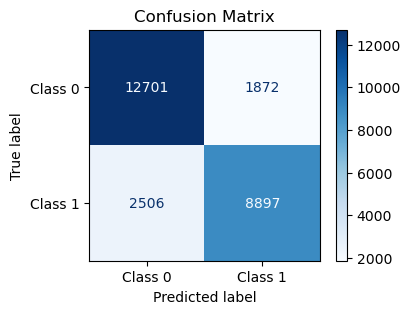

In [117]:
def run_model(model, X_train, y_train, X_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    roc_auc = roc_auc_score(y_test, y_pred)
    print("ROC_AUC = {}".format(roc_auc))
    print(classification_report(y_test,y_pred,digits=5))
    #confusion matrix
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=['Class 0', 'Class 1'], cmap='Blues', ax=ax)
    plt.title('Confusion Matrix')
    plt.show()
    return model, y_pred

logistic_model, logistic_predictions = run_model(LogisticRegression(), X_train, y_train, X_test)

--- Dummy Baseline ---
ROC_AUC = 0.5
              precision    recall  f1-score   support

           0    0.56102   1.00000   0.71878     14573
           1    0.00000   0.00000   0.00000     11403

    accuracy                        0.56102     25976
   macro avg    0.28051   0.50000   0.35939     25976
weighted avg    0.31474   0.56102   0.40325     25976



/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hayashieijun/Desktop/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

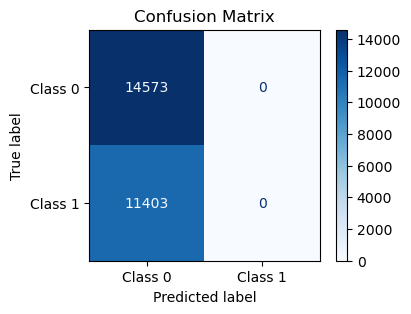


--- Logistic Regression Baseline ---
ROC_AUC = 0.8258882684439975
              precision    recall  f1-score   support

           0    0.83521   0.87154   0.85299     14573
           1    0.82617   0.78023   0.80254     11403

    accuracy                        0.83146     25976
   macro avg    0.83069   0.82589   0.82777     25976
weighted avg    0.83124   0.83146   0.83084     25976



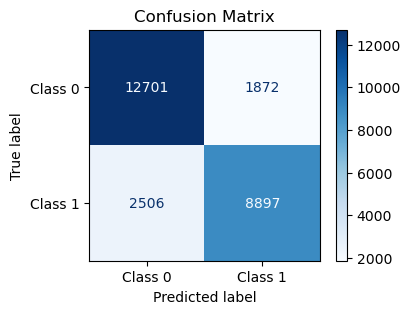

In [118]:
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier


dummy_model = DummyClassifier(strategy="most_frequent")
print("--- Dummy Baseline ---")
run_model(dummy_model, X_train, y_train, X_test)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

baseline_model = make_pipeline(StandardScaler(), LogisticRegression())
print("\n--- Logistic Regression Baseline ---")
baseline_model, baseline_preds = run_model(baseline_model, X_train, y_train, X_test)

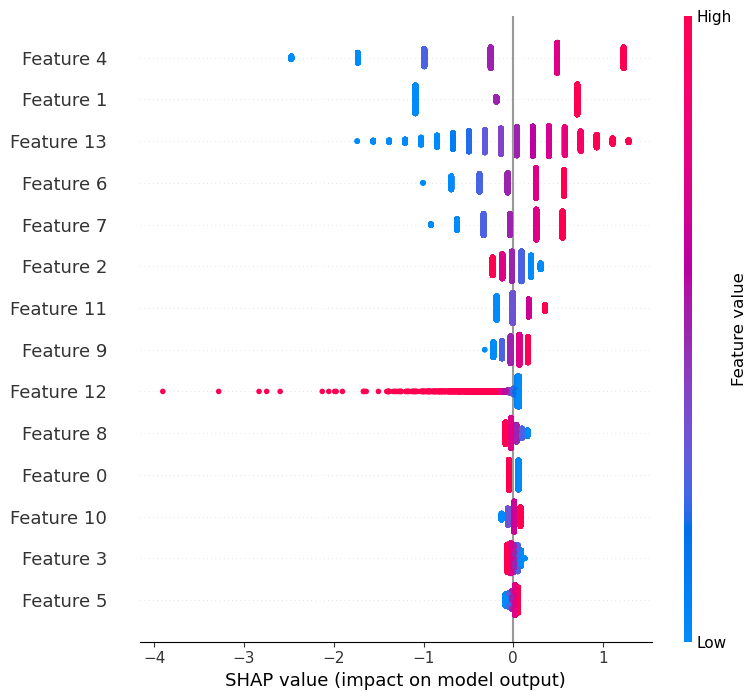

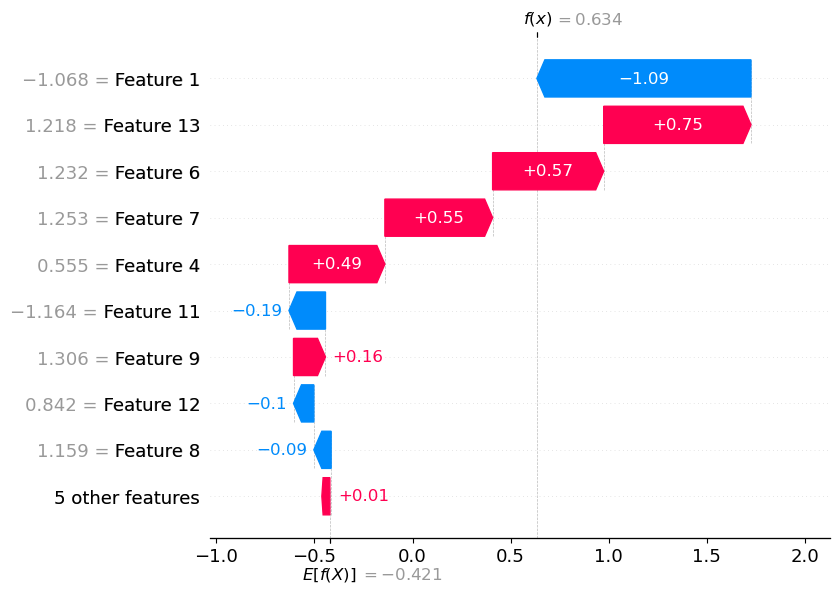

In [119]:
import shap

explainer = shap.LinearExplainer(logistic_model, X_train)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)
shap.plots.waterfall(explainer(X_test)[0])

Pipeline

In [120]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression

# ==========================================
# 1. Data Preparation
# ==========================================
df = pd.read_csv("/Users/hayashieijun/Desktop/airline-satisfaction-classification/data/test.csv")

# Map target to binary (Logistic Regression needs numeric labels)
y = df['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})
X = df.drop(columns=['satisfaction'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. Custom Feature Engineering Function
# ==========================================
def custom_feature_engineering(df):
    df = df.copy()
    
    # Binning continuous variables
    df['Age Group'] = pd.cut(df['Age'], bins=[0, 18, 30, 50, 100], labels=[0, 1, 2, 3]).astype(float)
    df['Flight Distance Group'] = pd.cut(df['Flight Distance'], bins=[0, 500, 1500, 3000, 5000], labels=[0, 1, 2, 3]).astype(float)
    
    # Total Delay (Handling NaNs is crucial for Logistic Regression)
    df['Total Delay'] = df['Departure Delay in Minutes'] + df['Arrival Delay in Minutes'].fillna(0)
    
    # Average Service Score
    service_cols = ['On-board service', 'Checkin service', 'Inflight service', 'Inflight wifi service']
    df['Service Score Average'] = df[service_cols].mean(axis=1)
    
    # Drop columns that are no longer needed for modeling
    # Note: We keep Gender, Customer Type, etc. here because they will be encoded in the next step
    cols_to_drop = [
        'id', 'Unnamed: 0', 'Age', 'Flight Distance', 
        'Departure Delay in Minutes', 'Arrival Delay in Minutes',
        'On-board service', 'Checkin service', 'Inflight service', 'Inflight wifi service',
        'Departure/Arrival time convenient', 'Gate location'
    ]
    return df.drop(columns=cols_to_drop, errors='ignore')

# Wrap the function for use in the Pipeline
feature_engineer = FunctionTransformer(custom_feature_engineering)

# ==========================================
# 3. Categorical Encoding & Preprocessing
# ==========================================
# Define the categorical columns and their order for OrdinalEncoder
categorical_features = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
ordinal_categories = [
    ['Male', 'Female'],                    
    ['disloyal Customer', 'Loyal Customer'], 
    ['Personal Travel', 'Business travel'],  
    ['Eco', 'Eco Plus', 'Business']      
]

preprocessor = ColumnTransformer(
    transformers=[
        ('ord_encode', OrdinalEncoder(categories=ordinal_categories), categorical_features)
    ],
    remainder='passthrough'
)

# ==========================================
# 4. Final Pipeline with Logistic Regression
# ==========================================
# Logistic Regression is sensitive to feature scale, so StandardScaler is a must.
full_pipeline = Pipeline(steps=[
    ('feature_eng', feature_engineer),
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, solver='lbfgs'))
])

# Train the model
full_pipeline.fit(X_train, y_train)

# Save to .pkl
joblib.dump(full_pipeline, "../pipelines/logistic_regression_pipeline.pkl")
print("Pipeline saved as logistic_regression_pipeline.pkl")

Pipeline saved as logistic_regression_pipeline.pkl
